## 4. Modeling

Three levels of ambition, in one project: **accuracy** (forecast the number), **structure** (explain a shock) and **decisions** (act on it). Each layer feeds the next, as the map below shows.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

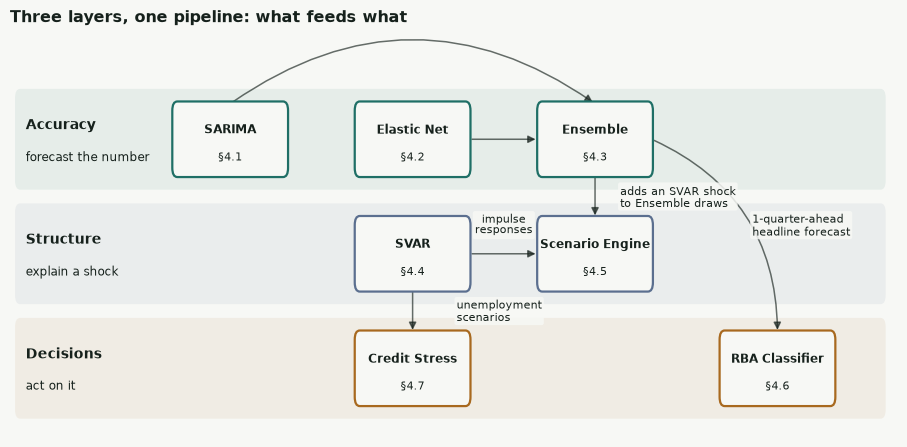

In [2]:
from matplotlib.patches import FancyBboxPatch

layers = [
    ("Accuracy", "forecast the number", ACCENT),
    ("Structure", "explain a shock", BLUE),
    ("Decisions", "act on it", HIGHLIGHT),
]

boxes = {   # key: (x_center, layer_row, label, section)
    "sarima": (0.5, 0, "SARIMA", "4.1"), "en": (3.4, 0, "Elastic Net", "4.2"), "ens": (6.3, 0, "Ensemble", "4.3"),
    "svar": (3.4, 1, "SVAR", "4.4"), "scen": (6.3, 1, "Scenario Engine", "4.5"),
    "credit": (3.4, 2, "Credit Stress", "4.7"), "rba": (9.2, 2, "RBA Classifier", "4.6"),
}

W, H = 1.8, 0.62
row_y = {0: 2.0, 1: 1.0, 2: 0.0}

fig, ax = plt.subplots(figsize=(9.2, 4.6))

# Background Layer Rows
for i, (name, job, color) in enumerate(layers):
    y = row_y[i]
    ax.add_patch(FancyBboxPatch((-2.9, y - 0.42), 13.8, 0.84, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=color, alpha=0.08, edgecolor="none"))
    ax.text(-2.75, y + 0.12, name, fontsize=10, fontweight="bold", va="center")
    ax.text(-2.75, y - 0.16, job, fontsize=8.5, va="center")

def pt(k, side):
    x, r, *_ = boxes[k]
    return {"r": (x + W / 2, row_y[r]), "l": (x - W / 2, row_y[r]),
            "b": (x, row_y[r] - H / 2), "t": (x, row_y[r] + H / 2)}[side]

# Draw Model Boxes
for k, (x, r, label, sec) in boxes.items():
    ax.add_patch(FancyBboxPatch((x - W / 2, row_y[r] - H / 2), W, H, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=PAPER, edgecolor=layers[r][2], linewidth=1.6, zorder=3))
    ax.text(x, row_y[r] + 0.08, label, ha="center", va="center", fontsize=8.6, fontweight="bold", zorder=4)
    ax.text(x, row_y[r] - 0.16, f"§{sec}", ha="center", va="center", fontsize=8, zorder=4)

def arrow(a, sa, b, sb, text="", rad=0.0, pos=None, ha="center"):
    p, q = pt(a, sa), pt(b, sb)
    ax.annotate("", xy=q, xytext=p, zorder=2,
                arrowprops=dict(arrowstyle="-|>", color=INK, alpha=0.65, lw=1.1, shrinkA=2, shrinkB=2,
                                connectionstyle=f"arc3,rad={rad}"))
    if text:
        # Subtle white background box around text to prevent line overlap
        bbox_style = dict(boxstyle="round,pad=0.2", facecolor=PAPER, edgecolor="none", alpha=0.85)
        ax.text(*pos, text, fontsize=7.8, ha=ha, va="center", zorder=5, bbox=bbox_style, linespacing=1.1)

# Shifted Arrow Positions & Arc Radii to ensure unblocked text
arrow("sarima", "t", "ens", "t", rad=-0.35)
arrow("en", "r", "ens", "l")
arrow("ens", "b", "scen", "t", "adds an SVAR shock\nto Ensemble draws", pos=(6.7, 1.5), ha="left")
arrow("svar", "r", "scen", "l", "impulse\nresponses", pos=(4.85, 1.25), ha="center")
arrow("svar", "b", "credit", "t", "unemployment\nscenarios", pos=(4.1, 0.5), ha="left")
arrow("ens", "r", "rba", "t", "1-quarter-ahead\nheadline forecast", rad=-0.32, pos=(8.8, 1.25), ha="left")

ax.set_xlim(-3.0, 11.1)
ax.set_ylim(-0.6, 2.95)
ax.axis("off")
ax.grid(False)
ax.set_title("Three layers, one pipeline: what feeds what", loc="left", fontsize=11.5, fontweight="bold")

fig.tight_layout()
plt.show()

Every equation below is taken from the code that actually runs, cited to its source file.
Every demo shares the project's own pinned forecast origin, **`2025Q4`**
(`svar.FORECAST_ORIGIN_PIN`), the same origin `svar.py` and `scenario.py` already
truncate to, and the one every checked-in report (SVAR, RBA classifier, credit stress,
the Streamlit live forecast tab) was generated at. The curated dataset has since grown
past that quarter as fresher ABS/RBA releases were pulled in, so a naive fresh refit on
"all available data" would silently land on a *later*, inconsistent origin. 4.3 below
truncates to the pin explicitly for that reason. 4.6 reads the project's saved exports, and 4.4 and 4.7 combine saved exports with live SVAR fits, all at
that same pinned origin.

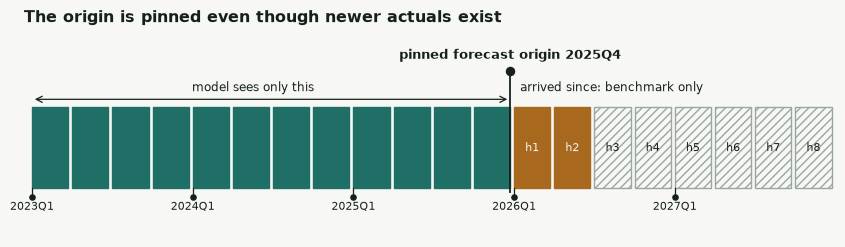

In [3]:
def mark_time(ax, x, y, label, offset, ha="left", size=8.5):
    """A dot on the exact point (x, y) and a thin leader line to a text label `offset` points away."""
    ax.scatter([x], [y], s=34, color=INK, edgecolor=PAPER, linewidth=1.1, zorder=6, clip_on=False)
    ax.annotate(label, (x, y), xytext=offset, textcoords="offset points", ha=ha, va="center", fontsize=size, zorder=7,
                bbox=dict(boxstyle="round,pad=0.15", facecolor=PAPER, edgecolor="none", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color=INK, alpha=0.6, linewidth=0.8, shrinkA=0, shrinkB=2))

from src.models import svar

origin = pd.Period(svar.FORECAST_ORIGIN_PIN, freq="Q")
df = pd.read_csv(CURATED)
last_actual = pd.Period(df.dropna(subset=["cpi_yoy"])["quarter"].iloc[-1], freq="Q")

quarters = pd.period_range(origin - 11, origin + 8, freq="Q")
fig, ax = plt.subplots(figsize=(8.6, 2.6))
for i, q in enumerate(quarters):
    if q <= origin:
        face, edge, txt, hatch = ACCENT, ACCENT, "", None
    elif q <= last_actual:
        face, edge, txt, hatch = HIGHLIGHT, HIGHLIGHT, "actual", None
    else:
        face, edge, txt, hatch = PAPER, MUTED, "", "////"
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, facecolor=face, edgecolor=edge, hatch=hatch, linewidth=1))
    if q > origin:
        h = q.ordinal - origin.ordinal
        ax.text(i + 0.45, 0.5, f"h{h}", ha="center", va="center", fontsize=8,
                color=PAPER if face == HIGHLIGHT else INK)
    if q.quarter == 1:
        ax.plot([i, i], [0, -0.1], color=INK, linewidth=0.9)
        ax.scatter([i], [-0.1], s=14, color=INK, zorder=5, clip_on=False)
        ax.text(i, -0.16, str(q), ha="center", va="top", fontsize=8)
o = list(quarters).index(origin)
ax.plot([o + 0.9] * 2, [-0.05, 1.45], color=INK, lw=1.3)
ax.scatter([o + 0.9], [1.45], s=34, color=INK, zorder=6)
ax.text(o + 0.9, 1.6, f"pinned forecast origin {origin}", ha="center", fontsize=9, fontweight="bold")
ax.text(o / 2, 1.2, "model sees only this", ha="center", fontsize=8.5)
ax.annotate("", xy=(0, 1.1), xytext=(o + 0.9, 1.1), arrowprops=dict(arrowstyle="<->", color=INK, lw=0.9))
first_act = list(quarters).index(origin + 1)
ax.text(first_act + 0.15, 1.2, "arrived since: benchmark only", ha="left", fontsize=8.5, color=INK)
ax.set_xlim(-0.2, len(quarters)); ax.set_ylim(-0.6, 1.95)
ax.axis("off"); ax.grid(False)
ax.set_title("The origin is pinned even though newer actuals exist", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()